In [34]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# append my path
project_root = os.path.abspath('..')
sys.path.append(project_root)

from utils.utils import *

In [35]:
data = load_saved_data("data_with_spikes_and_speed")

In [36]:
def fit_tuning_curves(
    data,
    session="B",
    stimulus="drifting_gratings",
    parameter="orientation",
    speed_phase=None,
):
    """Compute per-trial spike counts and fit a von Mises tuning curve per cell,
    in one pass over the stimulus table. 
    Also allows filtering trials based on running speed phase (e.g., still vs running).
    """
    session_data = data["sessions"][session]
    spikes = np.asarray(session_data["spikes"], dtype=float)
    stim_table = session_data["stim_tables"][stimulus]
    running_speed_phase = session_data["running_speed_phase"]

    n_cells = spikes.shape[0]
    # Hold spike counts and stimulus values for each cell
    counts_per_cell = [[] for _ in range(n_cells)]
    stim_per_cell = [[] for _ in range(n_cells)]

    for _, trial in stim_table.iterrows():
        start_idx = int(trial["start"])
        stop_idx = int(trial["end"])
        stim_value = trial[parameter]
        
        if speed_phase is not None:
            samples_in_phase = running_speed_phase[start_idx:stop_idx] == speed_phase
            if not np.any(samples_in_phase):
                continue
            # Count spikes only in the samples that match the specified speed phase
            spike_count = np.sum(spikes[:, start_idx:stop_idx][:, samples_in_phase], axis=1)
        else:
            spike_count = np.sum(spikes[:, start_idx:stop_idx], axis=1)
        
        # Store spike counts and stimulus values for each cell
        for cell_idx in range(n_cells):
            counts_per_cell[cell_idx].append(spike_count[cell_idx])
            stim_per_cell[cell_idx].append(stim_value)
            
    # Fit tuning curves for each cell
    fitted_params = []
    for cell_idx in range(n_cells):
        counts = np.asarray(counts_per_cell[cell_idx], dtype=float) # shape (n_trials,)
        stim = np.asarray(stim_per_cell[cell_idx], dtype=float) # shape (n_trials,)
        
        # Remove NaN or infinite values 
        valid = np.isfinite(counts) & np.isfinite(stim)
        counts = counts[valid]
        stim = stim[valid]

        params = tuningCurve(counts, stim)
        fitted_params.append(
            {
                "cell": cell_idx,
                "stimulus_parameters": stim,
                "spike_counts": counts,
                "van-mises-params": params,
                "speed_phase": speed_phase
            }
        )

    return fitted_params

In [37]:
def compute_tuning_significance(fitted_params, psi=2, niters=1000, random_seed=2046):
    """Permutation-based tuning significance per cell.
    """
    p_values = {}
    for entry in fitted_params:
        cell = int(entry["cell"])
        stim = np.asarray(entry["stimulus_parameters"], dtype=float)
        counts = np.asarray(entry["spike_counts"], dtype=float)

        p_value, q_abs, _ = testTuning(
            counts, stim, psi=psi, niters=niters, random_seed=random_seed
        )
        p_values[cell] = p_value

    return p_values

# Tuning analysis overview

In this notebook, we seek to assess how neurons are tuned to different grating orientation and directions. We fit modified von Mises models to the spike counts:

$$
f(\theta) = \exp\!\left(\alpha + \kappa \bigl(\cos(2(\theta-\phi))-1\bigr)+ \nu \bigl(\cos(\theta-\phi)-1\bigr)\right)
$$

where $\theta$ represents stimulus orientation ($0^\circ$--$360^\circ$ for drifting gratings and $0^\circ$--$150^\circ$ for static gratings), $\phi$ the preferred orientation, $\alpha$ the baseline firing rate, and $\kappa$ and $\nu$ the components encoding orientation and direction selectivity.

To assess significant tuning, we use permutation tests. For each neuron, the power of the first and second Fourier component of the fitted tuning curve is compared against shuffled data representing uniform tuning. (1: direction tuning, 2: orientation tuning). The fraction of permutations yielding a more extreme value than the observed data provides the p-value for direction and orientation selectivity.

For each neuron, this analysis was performed separately for spike counts collected during stillness ($\leq 5$ cm/s) and running ($>5$ cm/s).


## 1. Drifting gratings

### 1.1 Without movement

In [ ]:
# we look at direction tuning (first fourier component, use ground frequency)
PSI = 1 

In [40]:
fitted_params = fit_tuning_curves(
    data,
    session="A",
    stimulus="drifting_gratings",
    parameter="orientation",
    speed_phase=0 # still
)

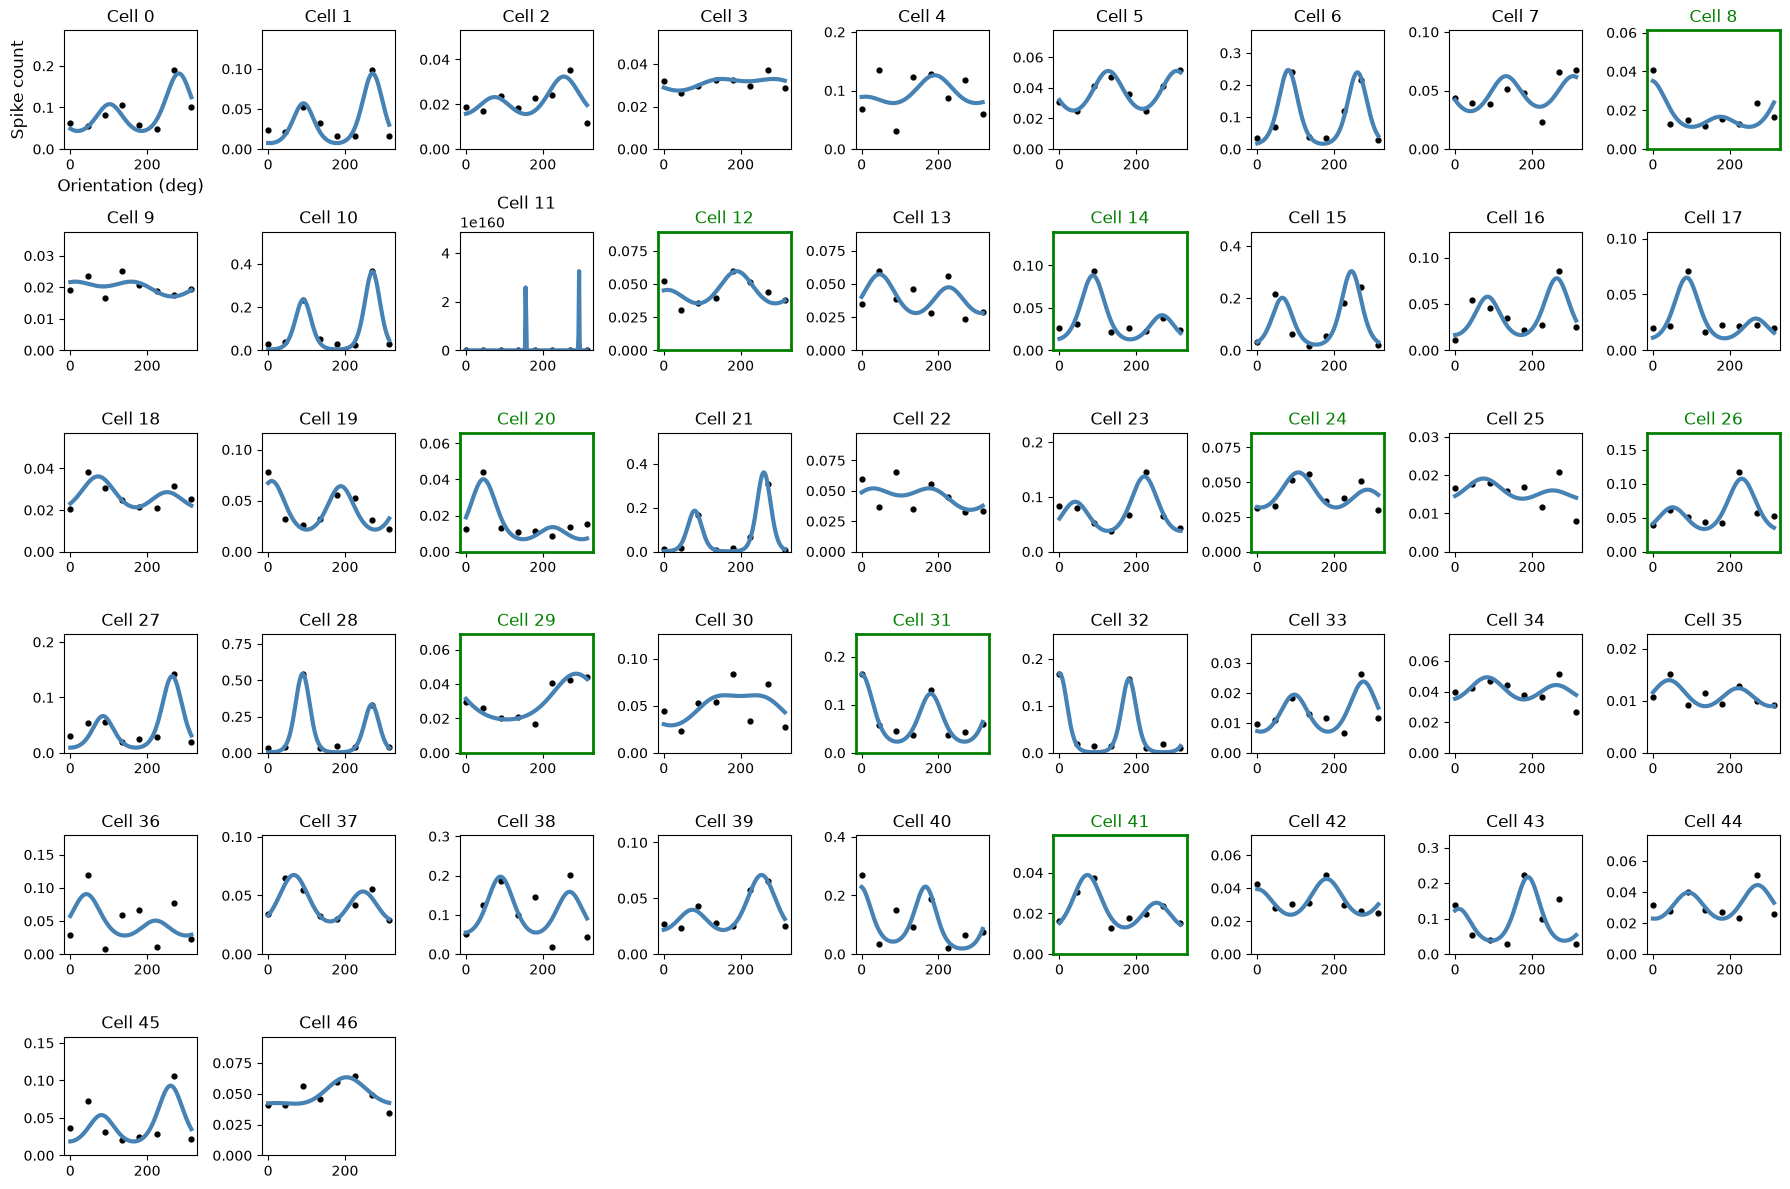

In [41]:
p_values = compute_tuning_significance(
    fitted_params,
    psi=PSI, # test orientation selectivity (Fourier mode)
    niters=1000,
    random_seed=2046
)

fig, axes = plot_tuning_curves(
    fitted_params,
    p_values=p_values,
    n_cols=9,
    alpha=0.05,
    psi=PSI,
    only_significant=False,
)
plt.show()

### 1.1 With Movement

In [42]:
fitted_params = fit_tuning_curves(
    data,
    session="A",
    stimulus="drifting_gratings",
    parameter="orientation",
    speed_phase=1 # running
)

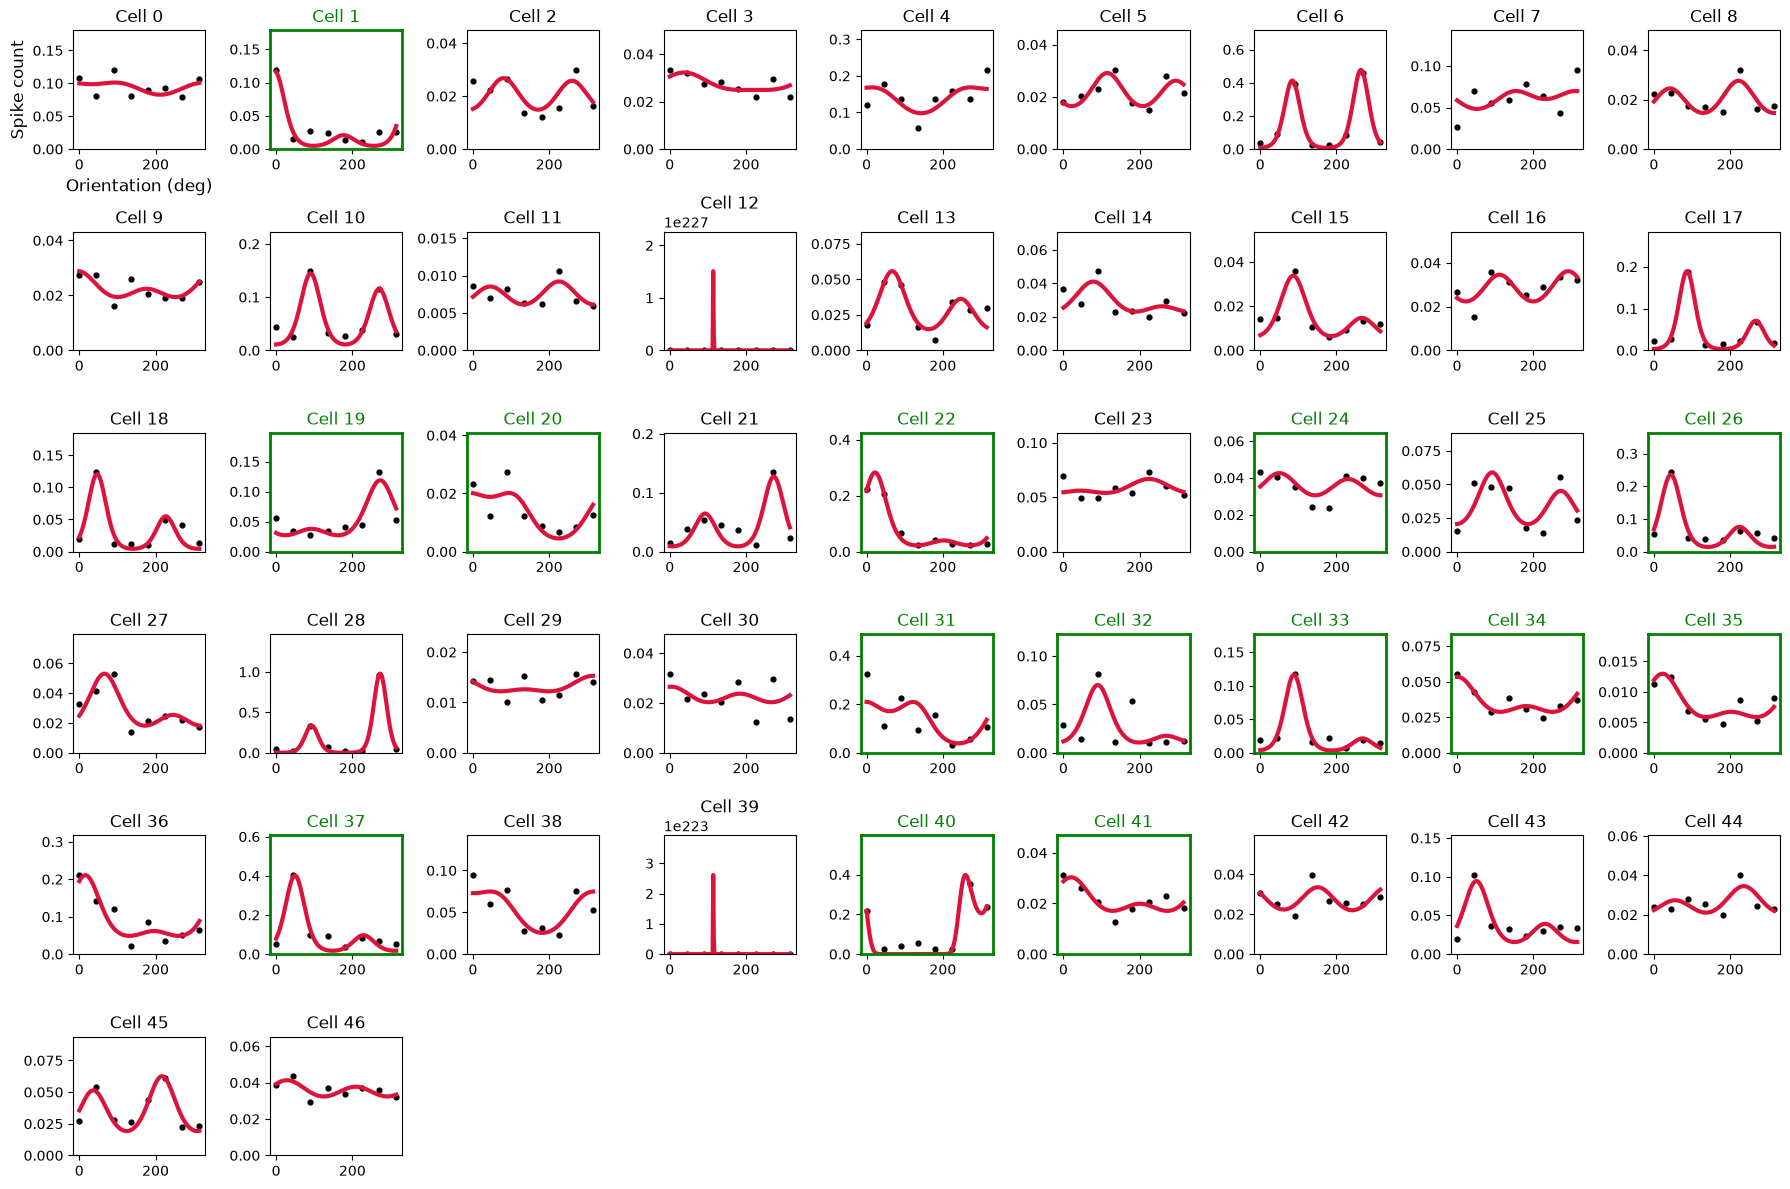

In [43]:
p_values = compute_tuning_significance(
    fitted_params,
    psi=PSI, # test orientation selectivity (Fourier mode)
    niters=1000,
    random_seed=2046
)

fig, axes = plot_tuning_curves(
    fitted_params,
    p_values=p_values,
    n_cols=9,
    alpha=0.05,
    psi=PSI,
    only_significant=False
)
plt.show()

For both locomotion phases, different neuron populations showed significant direction tuning to moving grating orientations. Even neurons that were significant in both phases (e.g., neuron 24) exhibited shifts in their tuning behavior.

## 2. Static gratings

### 2.1 Without movement

In [ ]:
# we look at orientation tuning (second fourier component, use second harmonic)
PSI = 2

In [45]:
fitted_params = fit_tuning_curves(
    data,
    session="B",
    stimulus="static_gratings",
    parameter="orientation",
    speed_phase=0 # still
)

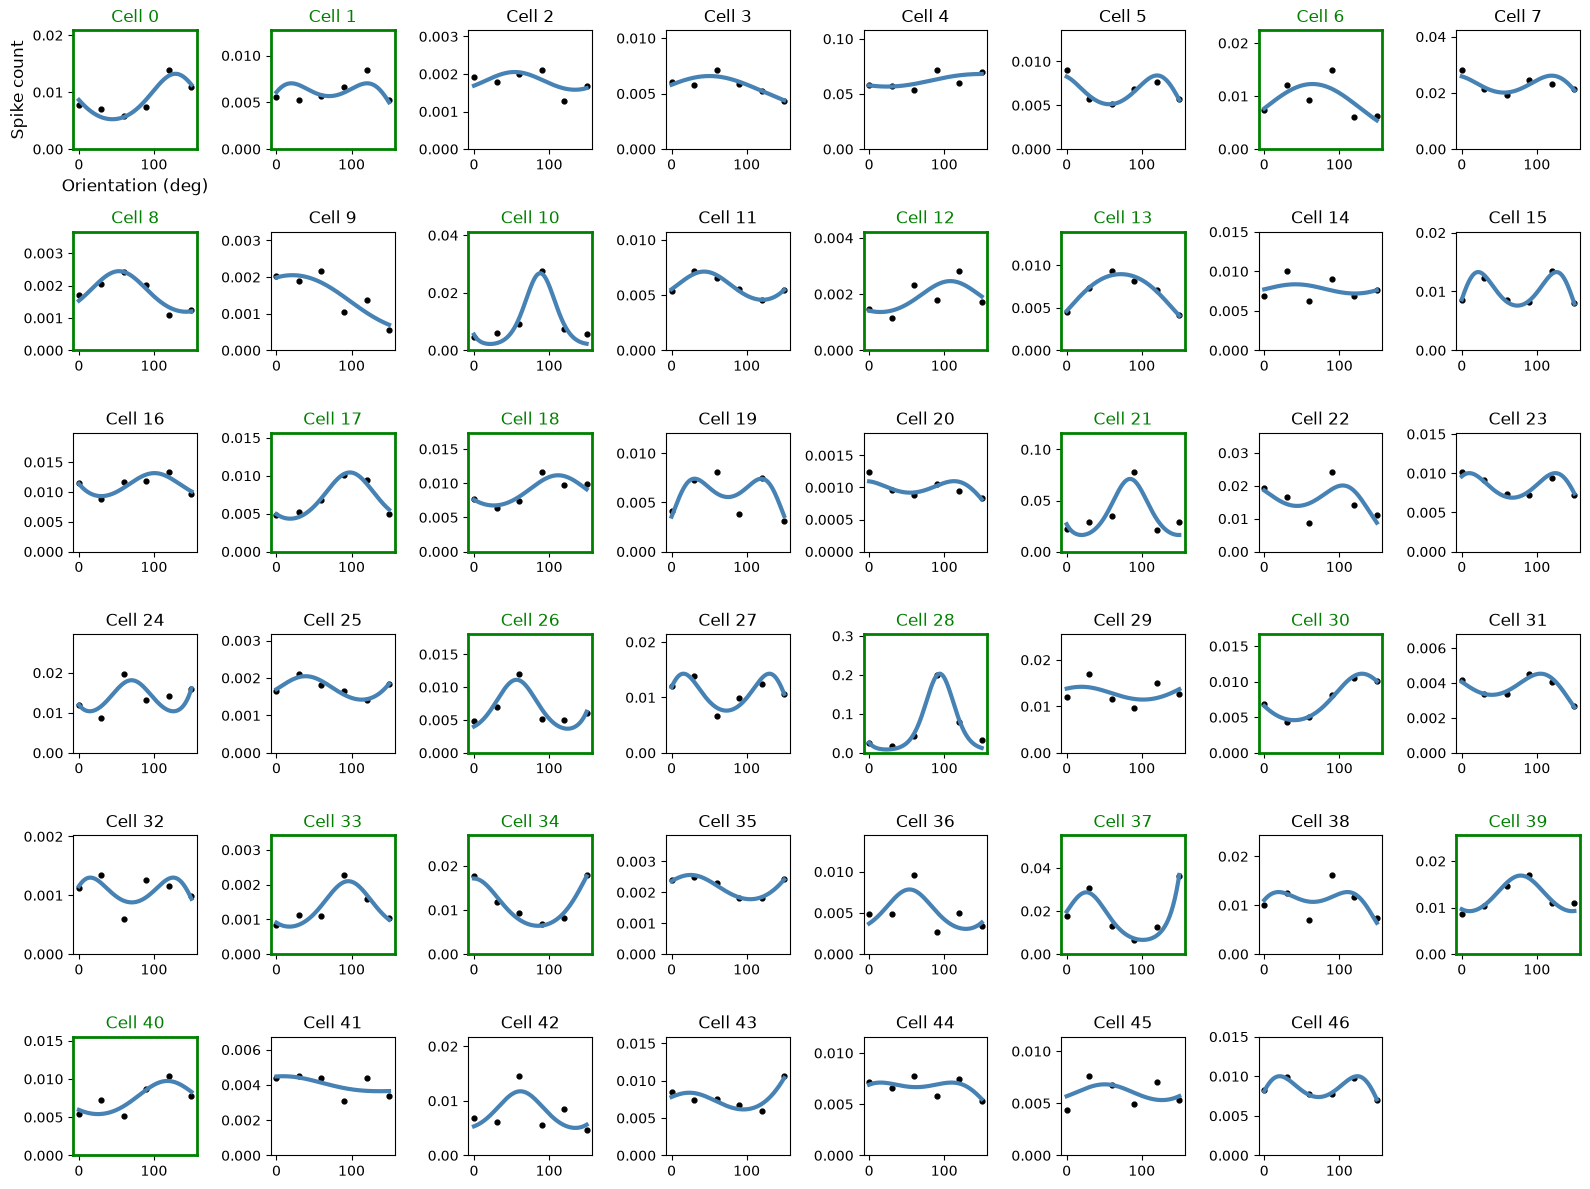

In [46]:
p_values = compute_tuning_significance(
    fitted_params,
    psi=PSI, # test orientation selectivity (Fourier mode)
    niters=1000,
    random_seed=2046
)

fig, axes = plot_tuning_curves(
    fitted_params,
    p_values=p_values,
    n_cols=8,
    alpha=0.05,
    psi=PSI,
    only_significant=False
)
plt.show()

### 2.2 With movement

In [47]:
fitted_params = fit_tuning_curves(
    data,
    session="B",
    stimulus="static_gratings",
    parameter="orientation",
    speed_phase=1 # running
)

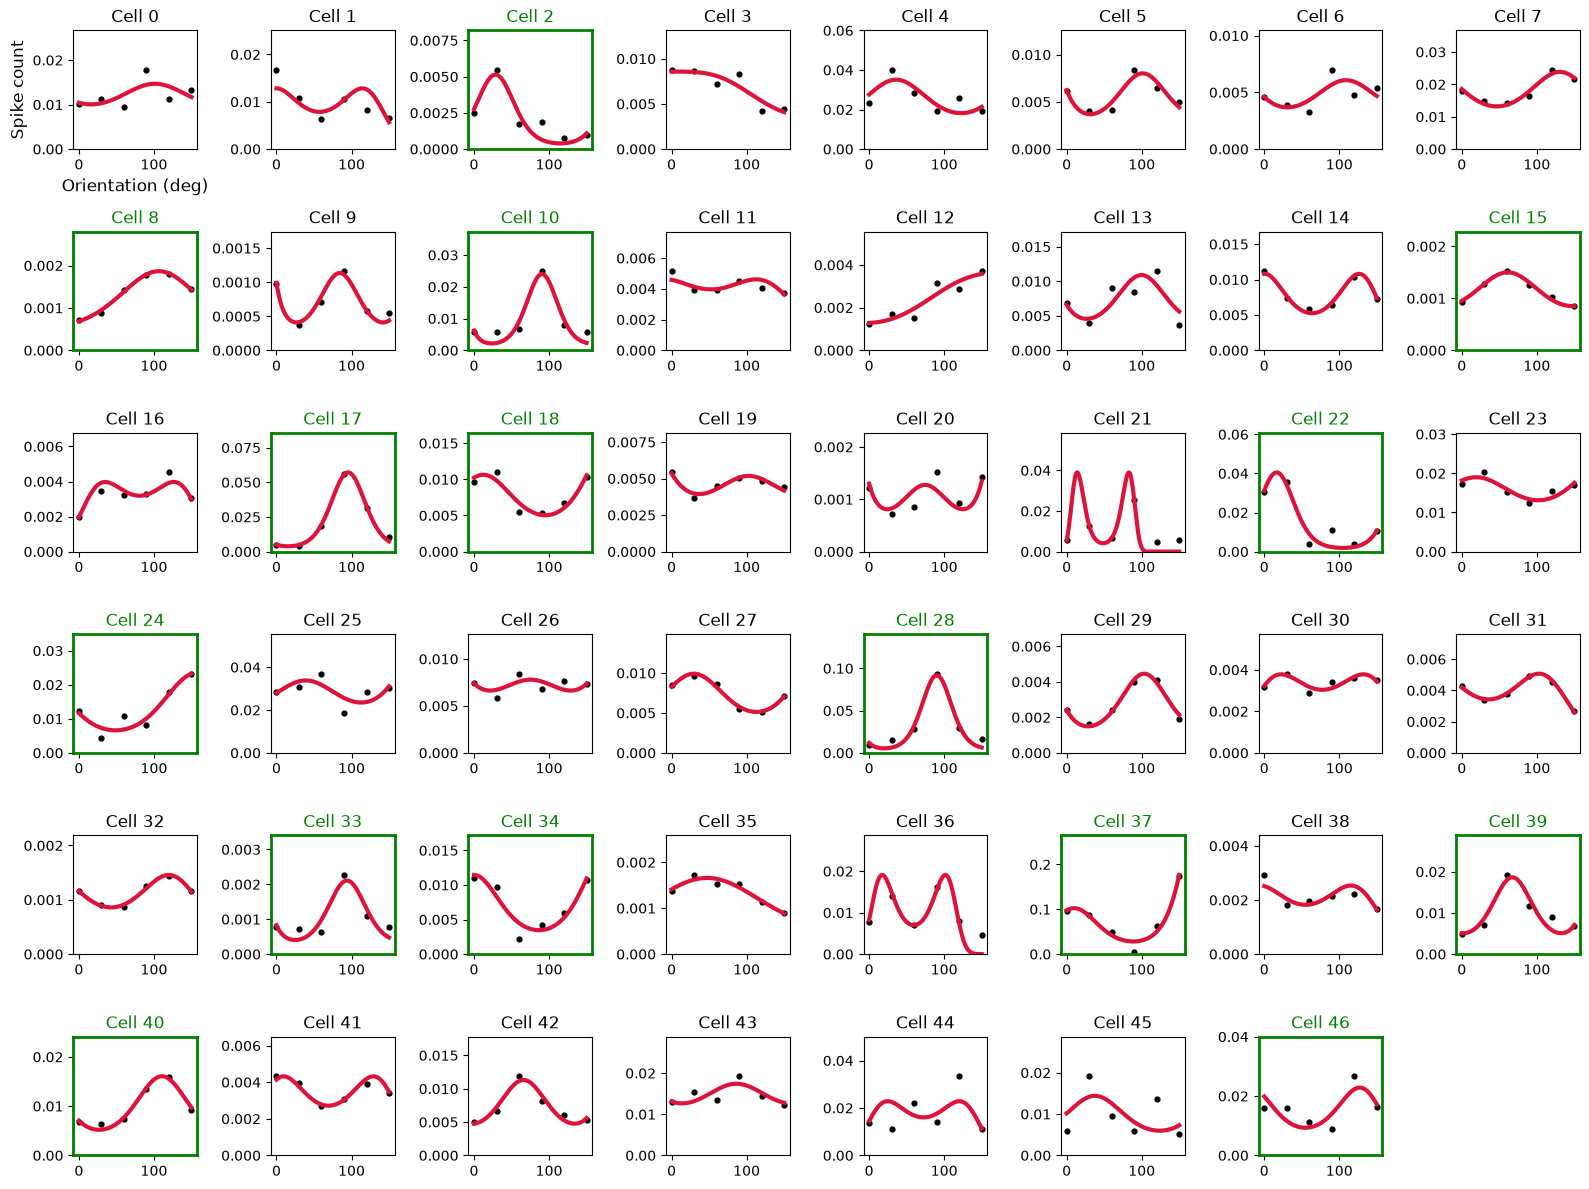

In [48]:
p_values = compute_tuning_significance(
    fitted_params,
    psi=PSI, # test orientation selectivity (Fourier mode)
    niters=1000,
    random_seed=2046
)

fig, axes = plot_tuning_curves(
    fitted_params,
    p_values=p_values,
    n_cols=8,
    alpha=0.05,
    psi=PSI, 
    only_significant=False,
)
plt.show()

We see that also when testing on orientation tuning with static gratings, there are differences in tuning behavior for different neurons.

## Intermediate Result

We found neurons tuned to different grating orientations and directions. Furthermore, distinct locomotion states recruited different tuned neuron populations, suggesting a potential population-level effect of locomotion during stimulus presentation.

However, these conclusions should be interpreted cautiously. Due to the limited amount of data, apparent changes in tuning may also arise from sampling variability, intrinsic neural variability, or measurement noise.

GPFA can provide a more thorough analysis of population-level neural variability and its relationship to running dynamics: